# Full Plasma (Core + Edge profiles)

This notebook demonstrates how to load and visualize a plasma object produced by `cherab`'s `Plasma` class using the `cherab.imas` interface.

The example test data was calculated by JINTRAC for an ITER 15 MA H-mode scenario.

In [1]:
import numpy as np
import ultraplot as uplt
from matplotlib.colors import SymLogNorm
from rich import print as rprint
from rich.table import Table

from cherab.core.math import sample3d, sample3d_grid
from cherab.imas.datasets import iter_jintrac
from cherab.imas.plasma import load_plasma

# Set dark background for plots
uplt.rc.style = "dark_background"

uplt.rc["title.borderwidth"] = 0

### Downloading ADAS files


In [2]:
from cherab.core.atomic import elements
from cherab.openadas.install import install_files

install_files(
    {
        "adf11scd": (
            (elements.neon, "adf11/scd96/scd96_ne.dat"),
            (elements.tungsten, "adf11/scd50/scd50_w.dat"),  # Not downloaded by default
        ),
        "adf11acd": (
            (elements.neon, "adf11/acd96/acd96_ne.dat"),
            (elements.tungsten, "adf11/acd50/acd50_w.dat"),  # Not downloaded by default
        ),
    },
    download=True,
)

Installing adf11/scd96/scd96_ne.dat...
Installing adf11/scd50/scd50_w.dat...
 - downloading ADF file 'adf11/scd50/scd50_w.dat' to '/home/runner/.cherab/openadas/repository/_download_cache/adf11/scd50/scd50_w.dat'


Installing adf11/acd96/acd96_ne.dat...
Installing adf11/acd50/acd50_w.dat...
 - downloading ADF file 'adf11/acd50/acd50_w.dat' to '/home/runner/.cherab/openadas/repository/_download_cache/adf11/acd50/acd50_w.dat'


## Define a function to plot plasma quantities

In [3]:
def plot_quantity(
    ax: uplt.axes.Axes,
    quantity: np.ndarray,
    extent: tuple[float, float, float, float],
    logscale: bool = False,
    symmetric: bool = False,
    cbar_kwargs: dict = None,
) -> uplt.axes.Axes:
    """Make a 2D plot of quantity, optionally on a log scale."""
    if logscale:
        # Plot lowest values (mainly 0's) on linear map, as log(0) = -inf.
        linthresh = np.percentile(np.unique(quantity), 1)
        norm = SymLogNorm(
            linthresh=float(max(linthresh, 1.0e-10 * quantity.max())),
            base=10,
        )
    else:
        norm = None
    # Sampled data is indexed as quantity(x, y),
    # but matplotlib's imshow expects quantity(y, x).
    if symmetric and not logscale:
        vmax = np.abs(quantity).max()
        image = ax.imshow(
            quantity.T,
            extent=extent,
            discrete=False,
            origin="lower",
            vmin=-vmax,
            vmax=vmax,
            cmap="berlin",
        )
    else:
        image = ax.imshow(
            quantity.T,
            extent=extent,
            discrete=False,
            origin="lower",
            norm=norm,
            cmap="gnuplot",
        )

    ax.colorbar(
        image,
        formatter="log" if logscale else None,
        tickminor=True,
        **(cbar_kwargs or {}),
    )

    ax.format(
        aspect="equal",
        xlabel="$R$ [m]",
        ylabel="$Z$ [m]",
        xlocator=1,
        ylocator=1,
    )

    return ax

## Retrieve ITER JINTRAC sample data

In [4]:
path = iter_jintrac()

## Load the plasma object

In [5]:
plasma = load_plasma(path)

12:44:03 INFO     Parsing data dictionary version 4.1.1 @dd_zip.py:89


12:44:03 INFO     Parsing data dictionary version 4.0.0 @dd_zip.py:89


/home/runner/work/imas/imas/src/cherab/imas/plasma/blend.py:181: RuntimeWarning: The 'get_slice' method is not implemented for the URI '/home/runner/.cache/cherab/imas/iter_scenario_53298_seq1_DD4_mod.nc'. Falling back to 'get' method because the returned IDS contains a single time slice.
  core_profiles_ids = get_ids_time_slice(


/home/runner/work/imas/imas/src/cherab/imas/plasma/blend.py:207: RuntimeWarning: The 'get_slice' method is not implemented for the URI '/home/runner/.cache/cherab/imas/iter_scenario_53298_seq1_DD4_mod.nc'. Falling back to 'get' method because the returned IDS contains a single time slice.
  edge_profiles_ids = get_ids_time_slice(
/home/runner/work/imas/imas/src/cherab/imas/plasma/equilibrium.py:104: RuntimeWarning: The 'get_slice' method is not implemented for the URI '/home/runner/.cache/cherab/imas/iter_scenario_53298_seq1_DD4_mod.nc'. Falling back to 'get' method because the returned IDS contains a single time slice.
  equilibrium_ids = get_ids_time_slice(


/home/runner/work/imas/imas/src/cherab/imas/plasma/equilibrium.py:188: RuntimeWarning: The 'get_slice' method is not implemented for the URI '/home/runner/.cache/cherab/imas/iter_scenario_53298_seq1_DD4_mod.nc'. Falling back to 'get' method because the returned IDS contains a single time slice.
  equilibrium_ids = get_ids_time_slice(


Warning! Unable to verify that the cell nodes are in the winding order.


Warning! Using average ion temperature for the D ion (z=+1).
Warning! Using average ion temperature for the He ion (z=+1).
Warning! Using average ion temperature for the He ion (z=+2).
Warning! Using average ion temperature for the Ne ion (z=+1).
Warning! Using average ion temperature for the Ne ion (z=+2).
Warning! Using average ion temperature for the Ne ion (z=+3).
Warning! Using average ion temperature for the Ne ion (z=+4).
Warning! Using average ion temperature for the Ne ion (z=+5).
Warning! Using average ion temperature for the Ne ion (z=+6).
Warning! Using average ion temperature for the Ne ion (z=+7).
Warning! Using average ion temperature for the Ne ion (z=+8).
Warning! Using average ion temperature for the Ne ion (z=+9).
Warning! Using average ion temperature for the Ne ion (z=+10).
Warning! Using average ion temperature for the W ion (z=+1).
Warning! Using average ion temperature for the W ion (z=+2).
Warning! Using average ion temperature for the W ion (z=+3).
Warning! Us

Warning! Species of type 'molecule' are currently not supported.
The following species will be skipped: D-D molecule


The loaded plasma object contains both core and edge profiles and all available species information shown below.

In [6]:
# Organize plasma species by symbol and charge
species = {}
for s in plasma.composition:
    symbol = s.element.symbol
    if symbol not in species:
        species[symbol] = []
    species[symbol].append(s)

# Sort species of each element by charge
for symbol in species:
    species[symbol].sort(key=lambda x: (x.element.atomic_number, x.element.atomic_weight, x.charge))

# Print table of plasma species
table = Table(title="Plasma Species")
table.add_column("Element", style="cyan", justify="right")
table.add_column("Charge", justify="left")
for symbol in species:
    charges = [s.charge for s in species[symbol]]
    charges_split = [charges[i : i + 10] for i in range(0, len(charges), 10)]
    charges_strs = [", ".join(f"{c:d}+" for c in split) for split in charges_split]
    charges_str = "\n".join(charges_strs)
    table.add_row(symbol, charges_str)
rprint(table)

                        Plasma Species                        
┏━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Element ┃ Charge                                           ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       D │ 0+, 1+                                           │
│       T │ 0+, 1+                                           │
│      He │ 0+, 1+, 2+                                       │
│      Ne │ 0+, 1+, 2+, 3+, 4+, 5+, 6+, 7+, 8+, 9+           │
│         │ 10+                                              │
│       W │ 0+, 1+, 2+, 3+, 4+, 5+, 6+, 7+, 8+, 9+           │
│         │ 10+, 11+, 12+, 13+, 14+, 15+, 16+, 17+, 18+, 19+ │
│         │ 20+, 21+, 22+, 23+, 24+, 25+, 26+, 27+, 28+, 29+ │
│         │ 30+, 31+, 32+, 33+, 34+, 35+, 36+, 37+, 38+, 39+ │
│         │ 40+, 41+, 42+, 43+, 44+, 45+, 46+, 47+, 48+, 49+ │
│         │ 50+, 51+, 52+, 53+, 54+, 55+, 56+, 57+, 58+, 59+ │
│         │ 60+, 61+, 62+, 63+, 64+, 65+, 66+, 67+, 68+, 69+ │
│         │ 70+, 71+, 72+, 73+, 74+                          │
└─────────┴──────────────────────────────────────────────────┘

## Plot several species' profiles

Define some constants related to sampling and plotting.

In [7]:
R_MIN, R_MAX = 4.0, 8.5
Z_MIN, Z_MAX = -4.5, 4.4
RES = 0.005  # resolution of grid in [m]
n_r = round((R_MAX - R_MIN) / RES) + 1
n_z = round((Z_MAX - Z_MIN) / RES) + 1
extent = [R_MIN, R_MAX, Z_MIN, Z_MAX]

### Electron density and temperature

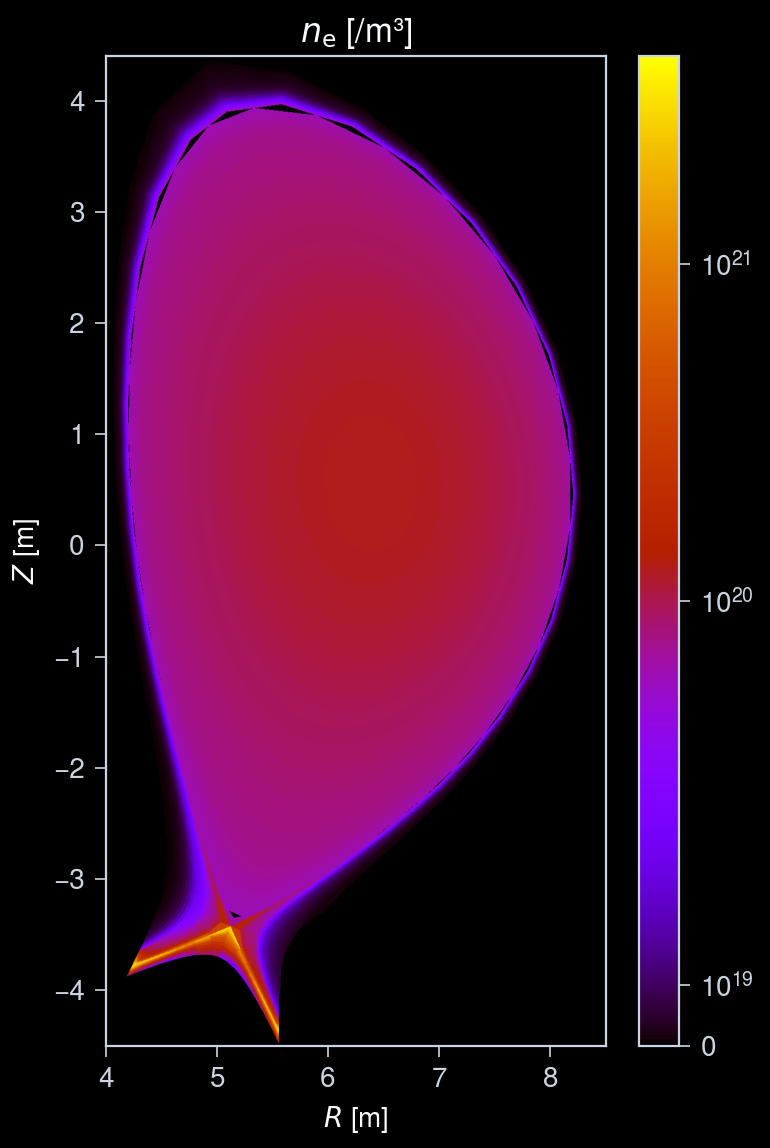

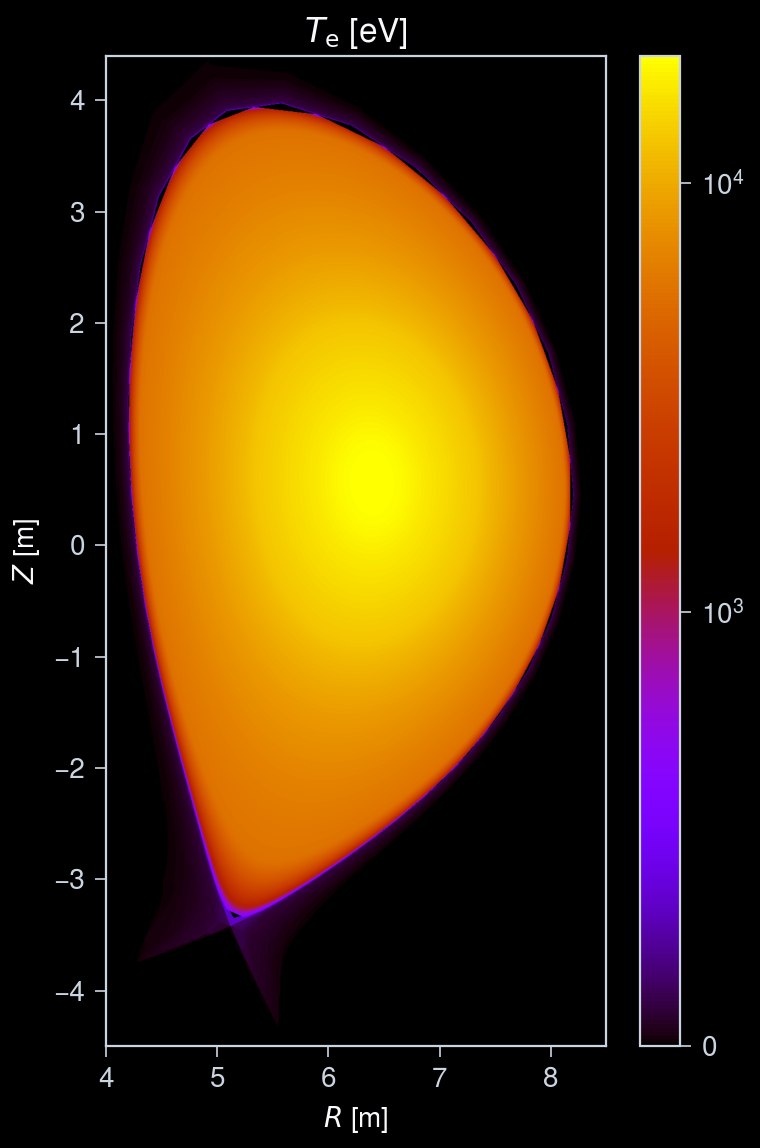

In [8]:
# Sample electron density
r_pts, _, z_pts, n_e = sample3d(
    plasma.electron_distribution.density,
    (R_MIN, R_MAX, n_r),
    (0, 0, 1),
    (Z_MIN, Z_MAX, n_z),
)
n_e = n_e.squeeze()

# Plot electron density
fig, ax = uplt.subplots()
ax = plot_quantity(
    ax,
    n_e,
    extent,
    logscale=True,
)
ax.format(
    title="$n_\\mathrm{e}$ [/m³]",
)

# Sample electron temperature
te_plasma = sample3d_grid(
    plasma.electron_distribution.effective_temperature,
    r_pts,
    [0],
    z_pts,
).squeeze()

# Plot electron temperature
fig, ax = uplt.subplots()
ax = plot_quantity(
    ax,
    te_plasma,
    extent,
    logscale=True,
)
ax.format(
    title="$T_\\mathrm{e}$ [eV]",
)

### Hydrogenic species (D, T) density and temperature

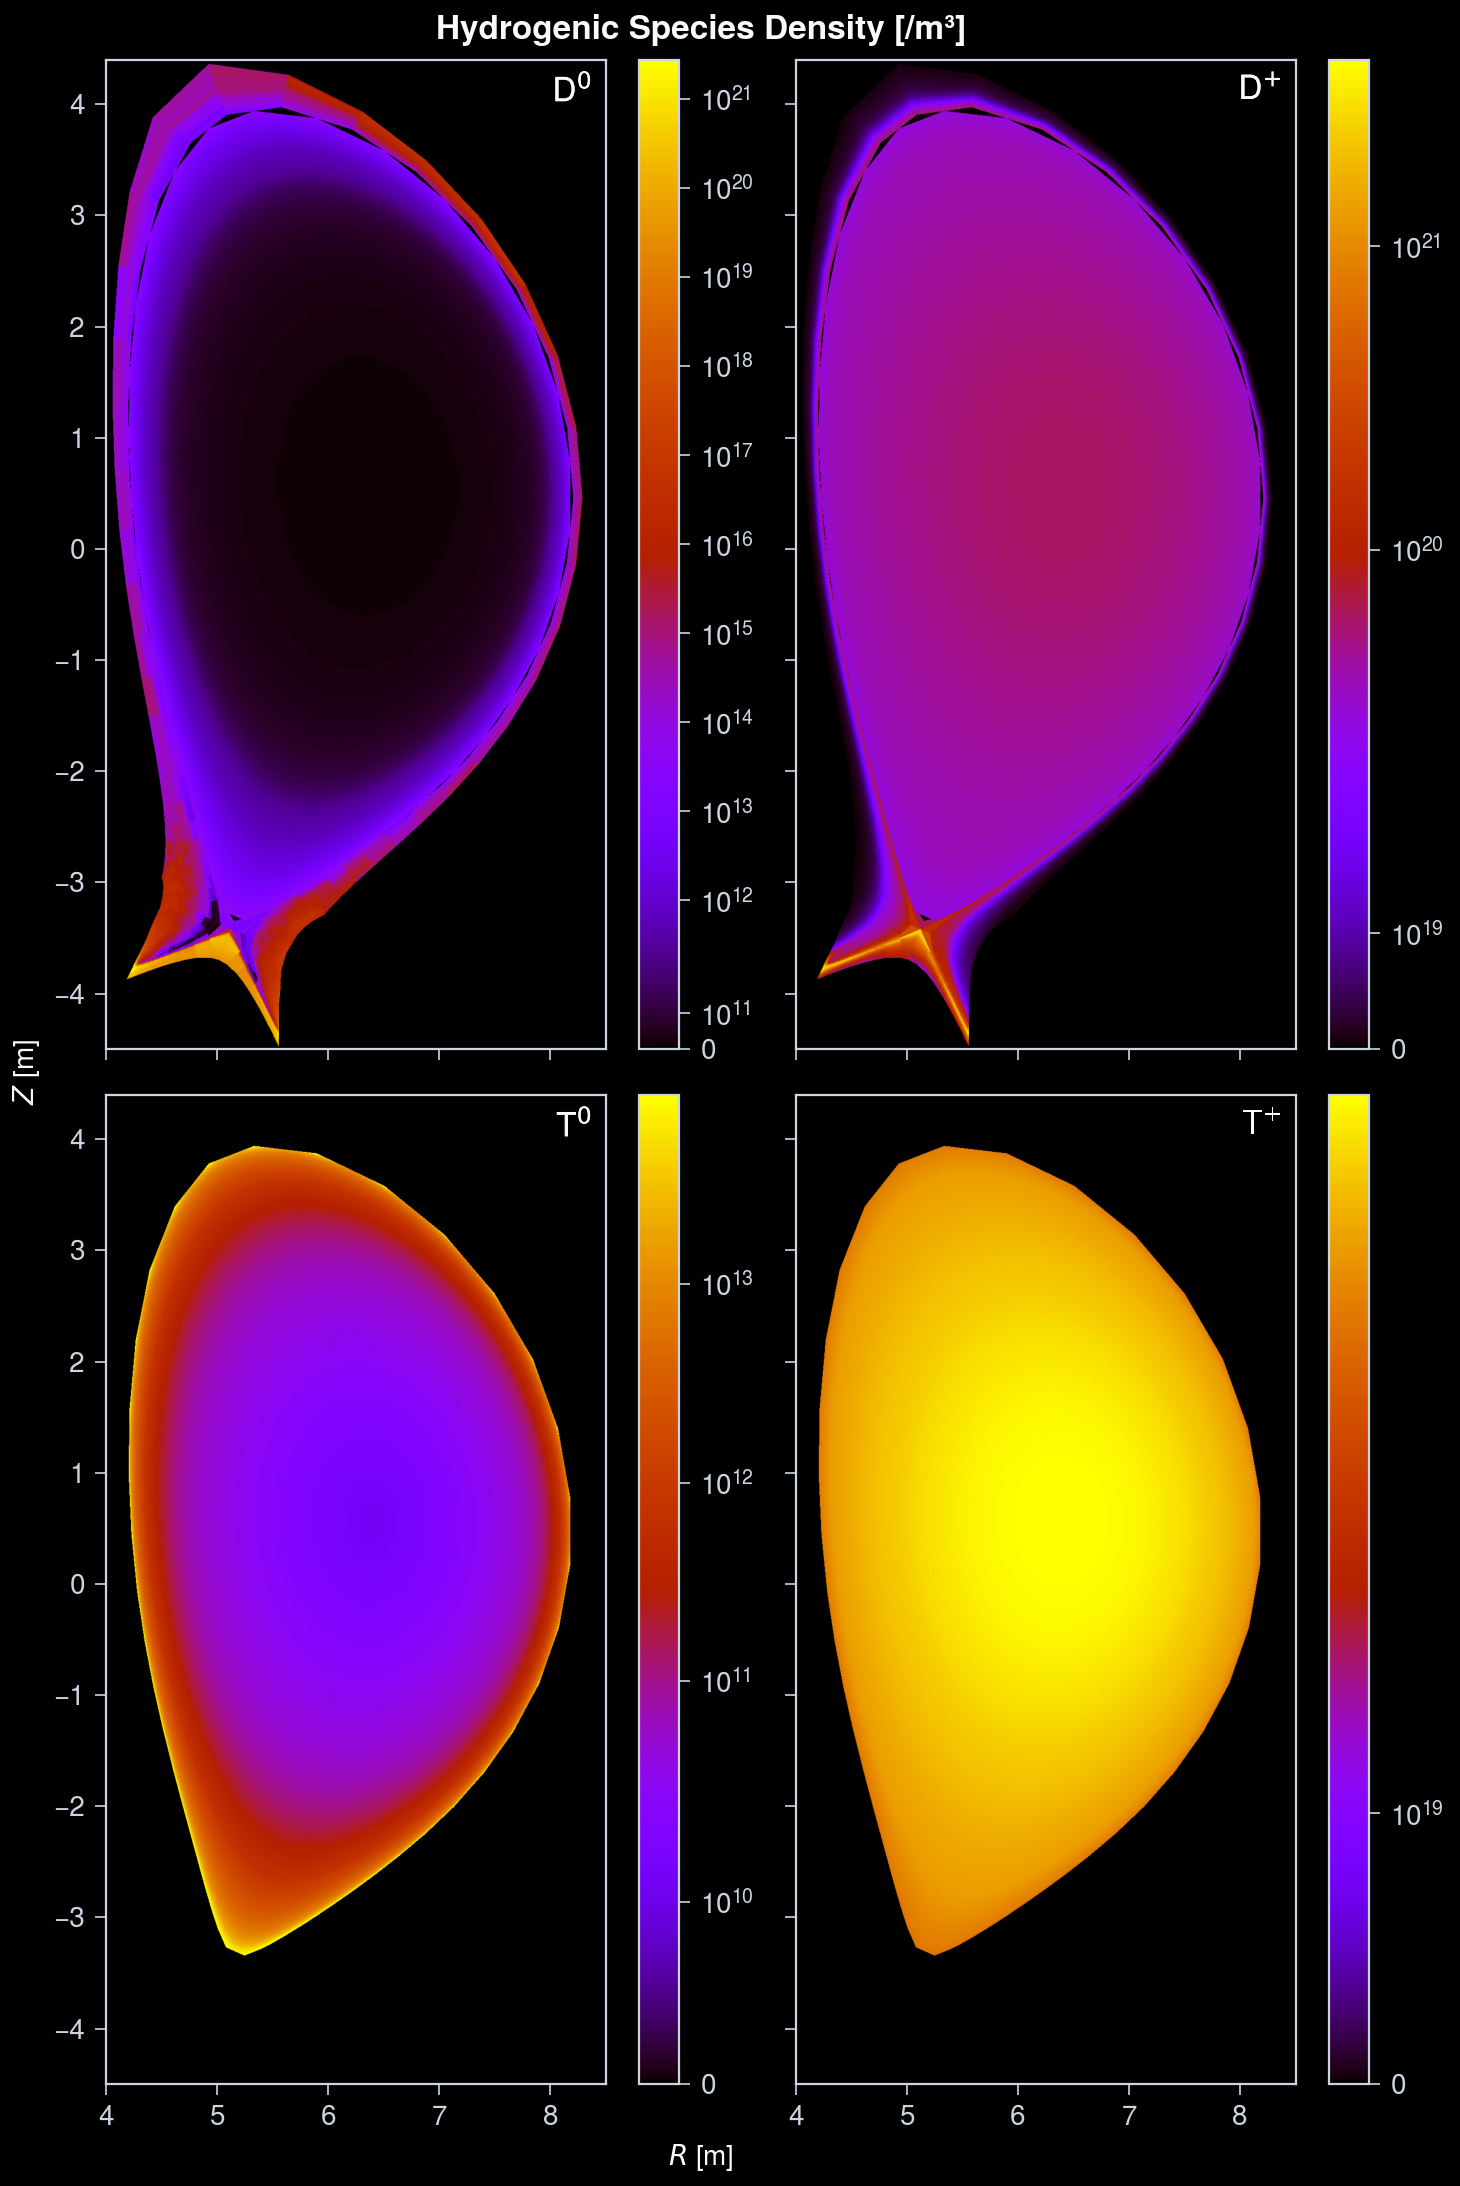

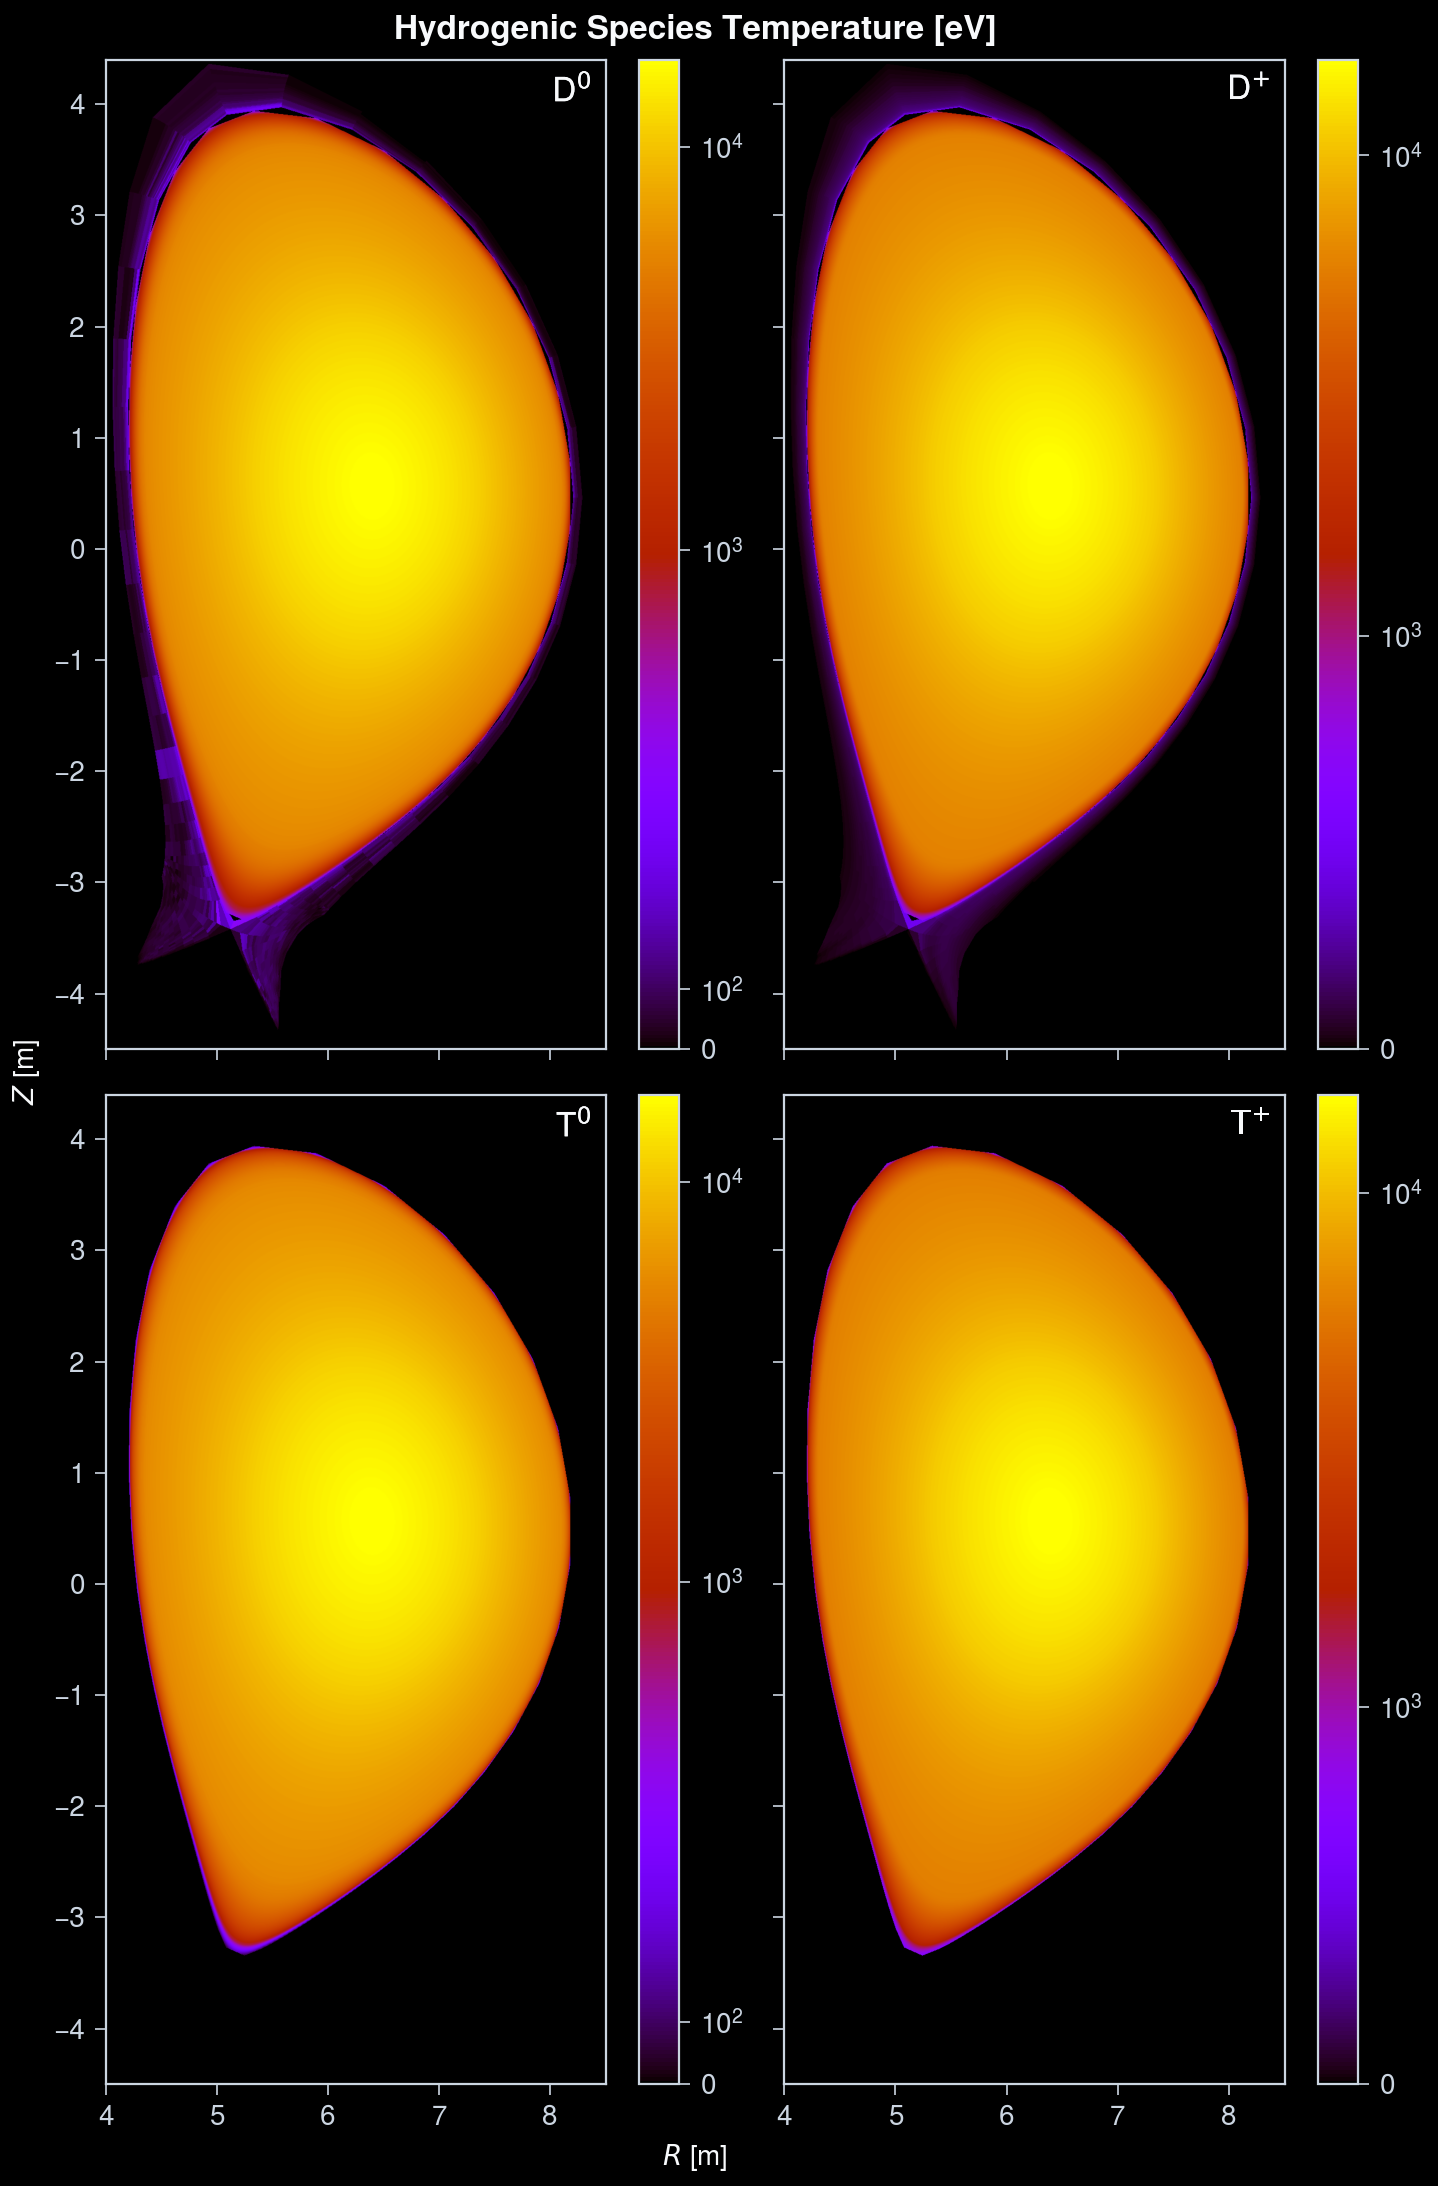

In [9]:
def species_label(species) -> str:
    """Construct element symbol with charge label"""
    if species.charge == 0:
        label = f"{species.element.symbol}$^{{0}}$"
    elif species.charge == 1:
        label = f"{species.element.symbol}$^{{+}}$"
    else:
        label = f"{species.element.symbol}$^{{{species.charge}+}}$"
    return label


# === Density Plot ===
fig, axs = uplt.subplots(
    nrows=2,
    ncols=2,
)
axs.format(suptitle="Hydrogenic Species Density [/m³]")
for i_row, s_list in enumerate([species["D"], species["T"]]):
    for i_col, s in enumerate(s_list):
        # Sample density
        density = sample3d_grid(
            s.distribution.density,
            r_pts,
            [0],
            z_pts,
        ).squeeze()

        # Plot density
        ax = plot_quantity(
            axs[i_row, i_col],
            density,
            extent,
            logscale=True,
        )
        ax.format(urtitle=species_label(s))


# === Temperature Plot ===
fig, axs = uplt.subplots(
    nrows=2,
    ncols=2,
)
axs.format(suptitle="Hydrogenic Species Temperature [eV]")
for i_row, s_list in enumerate([species["D"], species["T"]]):
    for i_col, s in enumerate(s_list):
        # Sample temperature
        temperature = sample3d_grid(
            s.distribution.effective_temperature,
            r_pts,
            [0],
            z_pts,
        ).squeeze()

        # Plot deutrium temperature
        ax = plot_quantity(
            axs[i_row, i_col],
            temperature,
            extent,
            logscale=True,
        )
        ax.format(urtitle=species_label(s))

### Other species' density

The number of charge states of tungsten is so large that we only plot every 10th charge state to avoid overcrowding the figure.

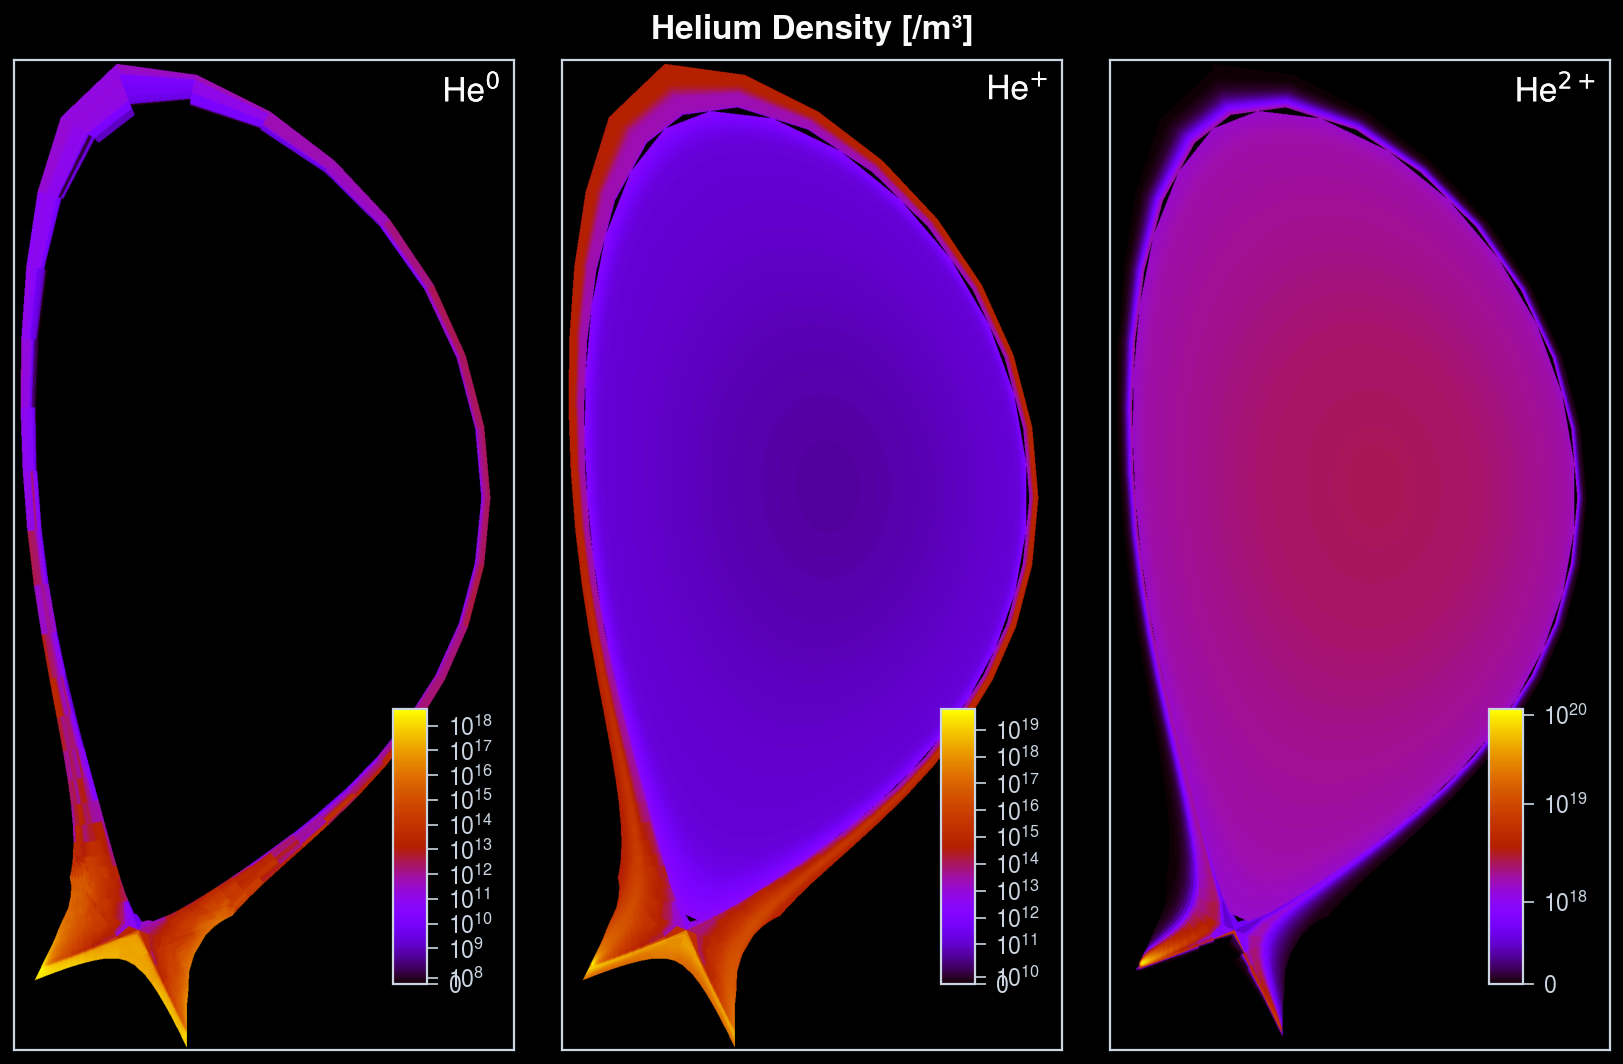

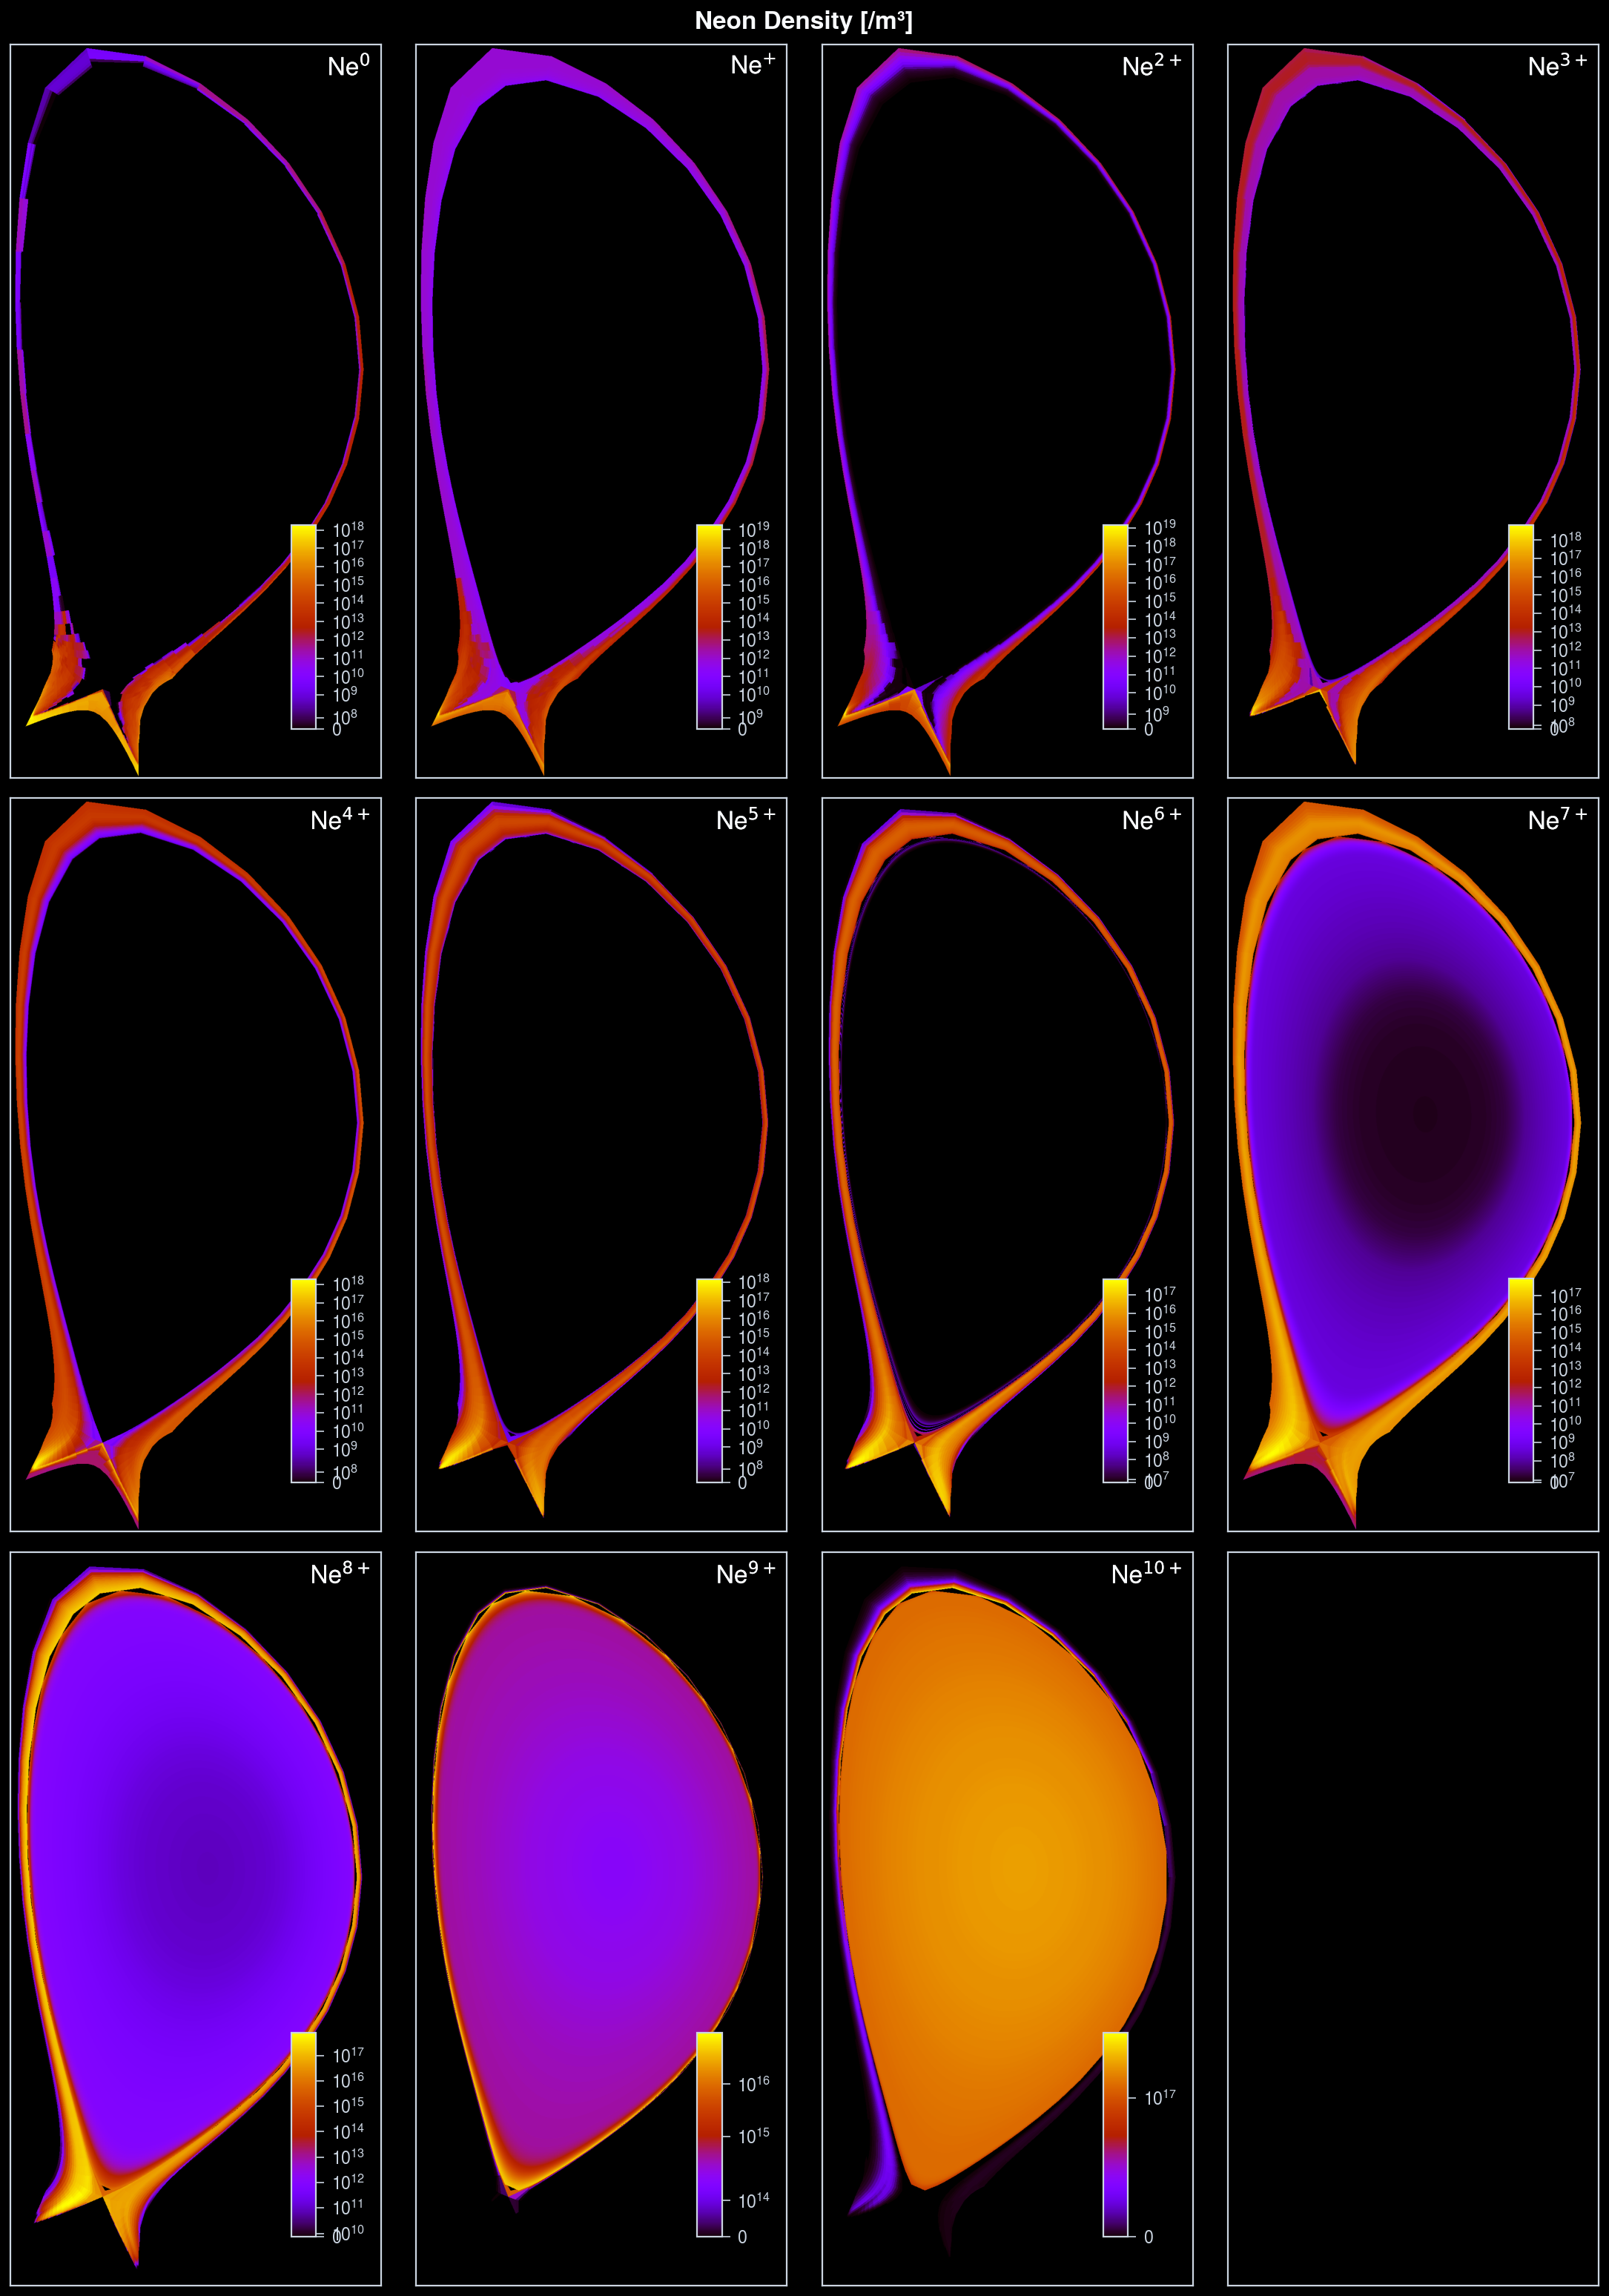

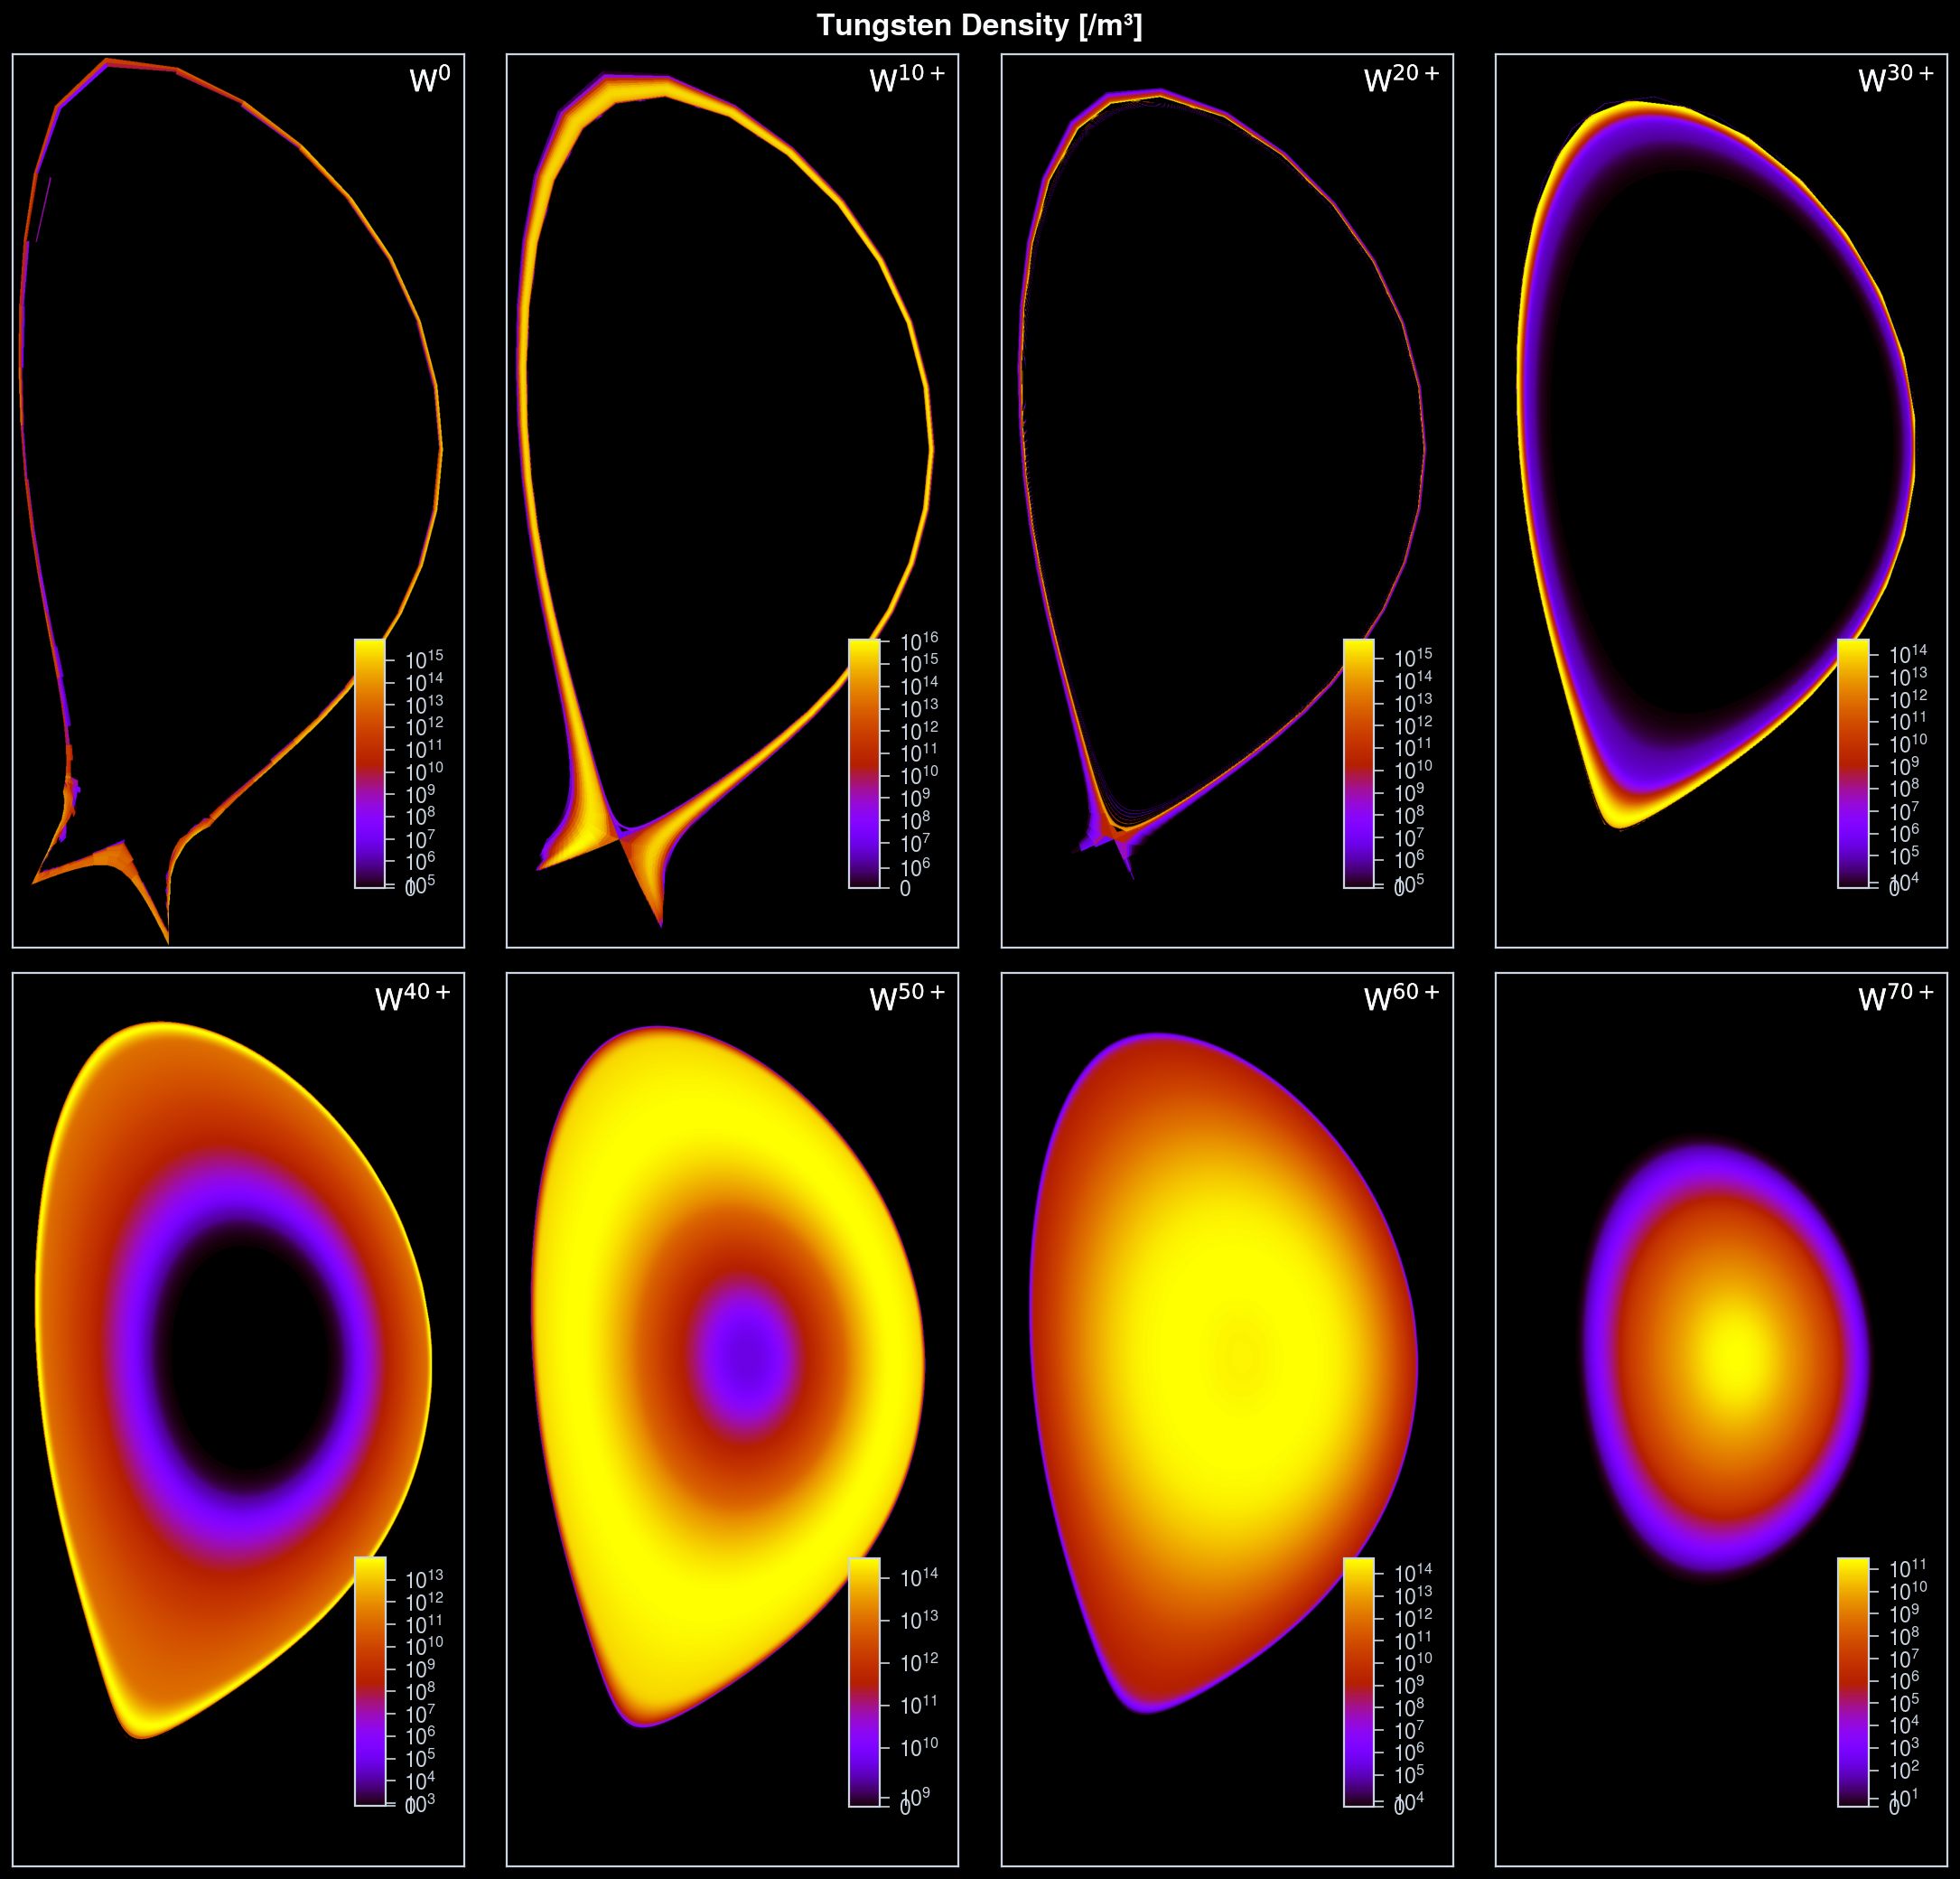

In [10]:
for s_list in [species["He"], species["Ne"], species["W"][::10]]:
    # Each element gets its own figure
    num_species = len(s_list)
    ncols = num_species if num_species < 4 else 4
    nrows = int(np.ceil(num_species / ncols))
    fig, axs = uplt.subplots(
        nrows=nrows,
        ncols=ncols,
    )

    for i_ax, s in enumerate(s_list):
        # Sample density
        density = sample3d_grid(
            s.distribution.density,
            r_pts,
            [0],
            z_pts,
        ).squeeze()

        # Make non-physical negative densities zero
        density[density <= 0] = 0.0

        # Plot density
        ax = plot_quantity(
            axs[i_ax],
            density,
            extent,
            logscale=True,
            cbar_kwargs=dict(
                loc="lr",
                orientation="vertical",
                ticklabelsize="small",
                length=5,
                frame=False,
            ),
        )
        ax.format(
            urtitle=species_label(s),
        )

    axs.format(
        suptitle=f"{s_list[0].element.name.capitalize()} Density [/m³]",
        xlabel="",
        ylabel="",
        xtickloc="neither",
        ytickloc="neither",
        linestyle="none",
    )

## Plot $Z_\mathrm{eff}$

Plot the effective charge profile, $Z_\mathrm{eff}$, which is calculated with all available species' densities.

In [11]:
def z_effective(x: float, y: float, z: float) -> float:
    """Calculate effective charge, $Z_\\mathrm{eff}$, at a given point.

    Need to implement error handling for points where zero density is sampled.
    """
    try:
        z_eff = plasma.z_effective(x, y, z)
    except ValueError:
        z_eff = 0.0

    return z_eff

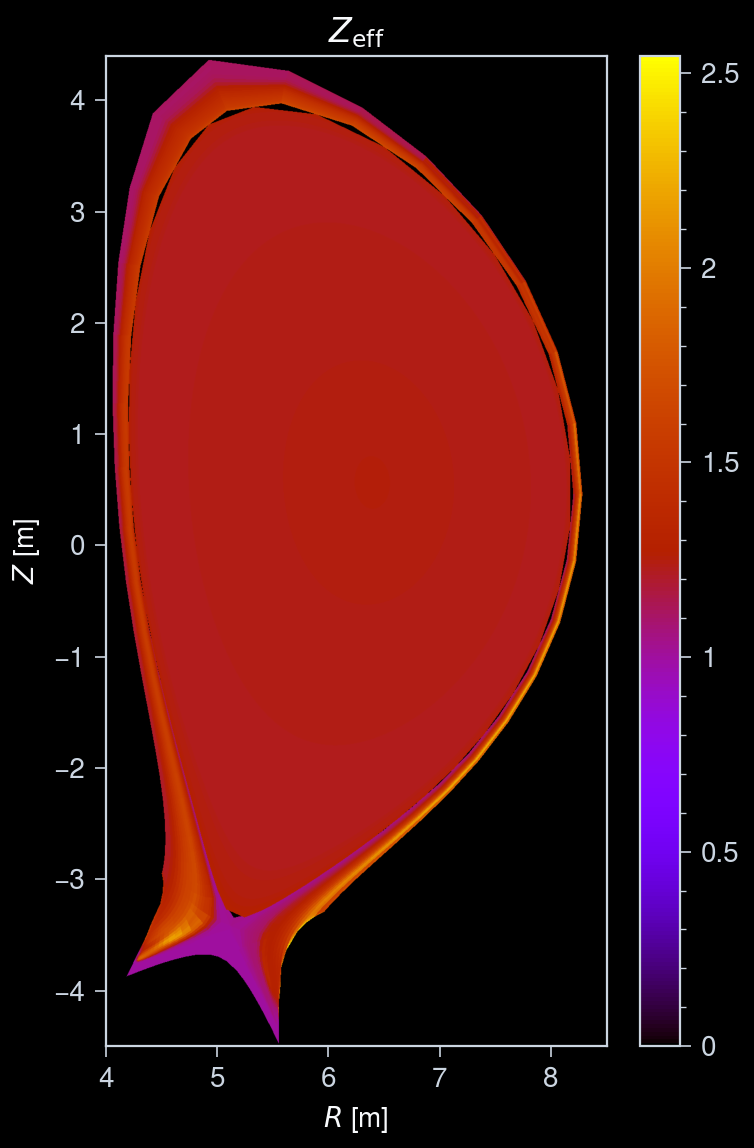

In [12]:
# Sample z_effecitivity
z_eff = sample3d_grid(
    z_effective,
    r_pts,
    [0],
    z_pts,
).squeeze()

# Plot z_effecitivity
fig, ax = uplt.subplots()
ax = plot_quantity(
    ax,
    z_eff,
    extent,
    logscale=False,
)
ax.format(
    title="$Z_\\mathrm{eff}$",
)